<a href="https://colab.research.google.com/github/Cnshimba/AI_EIARI4A_2026/blob/main/week7_exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Classification Dataset: Fashion MNIST

Fashion MNIST is a dataset of Zalando's article images, consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes (e.g., T-shirt, Trouser, Pullover, Dress, etc.). It's often used as a direct drop-in replacement for the original MNIST dataset for benchmarking machine learning algorithms, but it's more challenging than MNIST.

**Why it's good for ANN classification:**
*   **Image Data:** Introduces you to working with image data, which is a primary application of ANNs (especially Convolutional Neural Networks, CNNs).
*   **Multi-class Classification:** A good problem for developing multi-class classification models.
*   **Built-in Keras support:** Easy to load directly from Keras.

Here's how to load it using `keras.datasets`:

In [ ]:
import tensorflow as tf

# Load the Fashion MNIST dataset
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = tf.keras.datasets.fashion_mnist.load_data()

print("Fashion MNIST Training Features (X_train_fashion):")
print(f"Shape of training features: {X_train_fashion.shape}")
print(f"Shape of training labels: {y_train_fashion.shape}")
print("\nFashion MNIST Test Features (X_test_fashion):")
print(f"Shape of test features: {X_test_fashion.shape}")
print(f"Shape of test labels: {y_test_fashion.shape}")

import matplotlib.pyplot as plt

# Display the first image and its label
plt.imshow(X_train_fashion[0], cmap='gray')
plt.title(f"Label: {y_train_fashion[0]}")
plt.axis('off')
plt.show()


In [ ]:
import pandas as pd

# Assuming X_train_full is already loaded as a numpy array
X_train_full_df = pd.DataFrame(X_train_full)

print("First 5 rows of X_train_full:")
display(X_train_full_df.head())


### 2. Regression Dataset: California Housing Prices

This dataset contains aggregated data about houses in California districts. It's a classic choice for regression tasks, where the goal is to predict the median house value based on various features like population, median income, house age, etc. It's clean, well-structured, and easy to load.

**Why it's good for ANN regression:**
*   **Numerical Features:** All features are numerical, suitable for direct input into ANNs.
*   **Clear Target:** The target variable (median house value) is continuous.
*   **Moderate Size:** Large enough to demonstrate ANN capabilities but small enough to train quickly on a CPU.


Here's how to load it using `sklearn.datasets`:



In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load the dataset
housing = fetch_california_housing(as_frame=True)
X_housing, y_housing = housing.data, housing.target

print("California Housing Features (X):")
display(X_housing.head())
print("California Housing Target (y):")
display(y_housing.head())
print(f"Shape of features: {X_housing.shape}")
print(f"Shape of target: {y_housing.shape}")


# Assuming X_housing and y_housing are your full feature and target datasets

# 1. Split the data into 60% training and 40% (temp) for test+validation
X_train_60, X_temp, y_train_60, y_temp = train_test_split(
    X_housing, y_housing, test_size=0.4, random_state=42
)

# 2. Split the 40% temp data into two halves: 20% test and 20% validation
# (0.50 of 0.40 is 0.20)
X_val_20, X_test_20, y_val_20, y_test_20 = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"X_train (60%) shape: {X_train_60.shape}")
print(f"y_train (60%) shape: {y_train_60.shape}")
print(f"X_validation (20%) shape: {X_val_20.shape}")
print(f"y_validation (20%) shape: {y_val_20.shape}")
print(f"X_test (20%) shape: {X_test_20.shape}")
print(f"y_test (20%) shape: {y_test_20.shape}")

# 2. Feature Scaling
# It's important to scale features for neural networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_60)
X_val_scaled = scaler.transform(X_val_20)
X_test_scaled = scaler.transform(X_test_20)

print("\nFirst 5 rows of scaled X_train_scaled:")
display(pd.DataFrame(X_train_scaled).head())

California Housing Features (X):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


California Housing Target (y):


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


Shape of features: (20640, 8)
Shape of target: (20640,)
X_train (60%) shape: (12384, 8)
y_train (60%) shape: (12384,)
X_validation (20%) shape: (4128, 8)
y_validation (20%) shape: (4128,)
X_test (20%) shape: (4128, 8)
y_test (20%) shape: (4128,)

First 5 rows of scaled X_train_scaled:


,0,1,2,3,4,5,6,7
0,1.057267,0.513041,0.155101,-0.091104,0.081628,-0.061010,-0.724300,0.478607
1,-1.268202,-1.635105,1.862753,1.858942,-1.215031,-0.038609,-1.093856,1.798471
2,-0.903124,-0.043886,-0.254026,-0.229878,0.514737,-0.064798,1.441581,-0.592227
3,0.459045,1.149529,0.172837,-0.198391,-0.411067,-0.066304,0.898941,-1.384146
4,-0.321637,-1.475983,-0.612419,-0.101909,0.536081,-0.083831,0.838128,-1.160018


Now that the data is prepared, let's define and train a new ANN model using this scaled data:

For the first layer of a Keras `Sequential` model (and often for other model types as well, though the syntax might differ), you must tell the model the shape of the data it should expect for a single input sample. This is typically done using the `input_shape` argument.

Here's why it's crucial:

1. **Model Building**: Keras needs this information to correctly build the internal structure of your neural network. It uses the `input_shape` to determine the number of weights and biases for the connections between the input layer and the first hidden layer.

2. **Compatibility** : It ensures that the model can correctly receive and process your data. If the `input_shape` doesn't match the actual shape of your input samples (excluding the batch dimension), you'll encounter errors during training or prediction.

While Keras can sometimes infer the `input_shape` if you define the input layer explicitly (e.g., `tf.keras.Input(shape=(num_features,)))` or when using the functional API, for a Sequential model where your first layer is a Dense layer, input_shape is the standard and necessary way to provide this information.


`input_shape=X_train_scaled.shape[1:]:` This part, `input_shape=(8,)`, is crucial and must correctly tell the model how many features are in each input sample. If your data has 8 features, input_shape should reflect that.

`tf.keras.layers.Dense(X, ...):` The X inside Dense(X, ...) specifies the number of neurons (or units) in that particular hidden layer. This is a hyperparameter that you, as the model designer, choose. It can be 8, 30, 64, 128, or any other reasonable positive integer.

* Why would you choose something other than the number of features? The neurons in hidden layers are responsible for learning complex patterns and transformations of the input data. Having more or fewer neurons than the input features allows the network to project the data into a different dimensional space, potentially capturing more intricate relationships.

* In this example:
When you see `Dense(30, ...):` the first hidden layer has 30 neurons. It took 8 input features and transformed them into 30 outputs.





In [6]:
# 3. Define the Keras model (similar to model_00, but adjusted for potentially scaled data)
model_housing = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=X_train_scaled.shape[1:]),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model_housing.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629 (2.46 KB)

 Trainable params: 629 (2.46 KB)

 Non-trainable params: 0 (0.00 B)

###Parameters for the first layer:
Here's how it's calculated:
* **Weights:** For each of the 32 neurons, there are 8 input connections, meaning 8 weights per neuron. So, `32 neurons * 8 weights/neuron = 256 weights`.
* **Biases:** Each of the 32 neurons also has its own bias term. So, `32 neurons * 1 bias/neuron = 32 biases`.
* **Total Parameters**: `256 weights + 32 biases = 288 parameters`

In [8]:
# 4. Compile the model
model_housing.compile(
    loss=tf.keras.losses.MeanSquaredError(), # Using MSE is common for regression
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

Before the neural network can start learning from data, it needs to know how to measure its performance and how to improve itself.

In your code, the compile method takes three key arguments:

1. Loss Function `(loss=tf.keras.losses.MeanSquaredError()):` This is the model's 'ruler.' It calculates the difference between the model's prediction and the actual target value. For regression (like predicting house prices), **Mean Squared Error (MSE)** is standard. It squares the errors, meaning larger mistakes are penalized much more heavily than small ones.

2. Optimizer `(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)):` ***If the loss function tells the model how wrong it is, the optimizer is the 'driver' that decides how to fix it***. It uses the loss value to adjust the weights of the neurons. Adam is a very popular choice because it automatically adjusts the learning rate as it trains, making it efficient and stable.

3. Metrics `(metrics=[tf.keras.metrics.MeanAbsoluteError()]):` These are purely for you to read. While the model uses the Loss to update its weights, it reports the Metric so you can understand the error in a more human-readable way. **Mean Absolute Error (MAE)** tells you exactly how many dollars (in thousands) the model is off by on average.

In [ ]:
# 5. Train the model
print("\nTraining the model...")
history = model_housing.fit(
    X_train_scaled, y_train_60, epochs=1000, batch_size=16, validation_data=(X_val_scaled, y_val_20), verbose=1
)


Training the model...
Epoch 1/1000
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2238 - mean_absolute_error: 0.3232 - val_loss: 0.2525 - val_mean_absolute_error: 0.3395
Epoch 2/1000
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2217 - mean_absolute_error: 0.3222 - val_loss: 0.2622 - val_mean_absolute_error: 0.3585
Epoch 3/1000
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2230 - mean_absolute_error: 0.3228 - val_loss: 0.2566 - val_mean_absolute_error: 0.3471
Epoch 4/1000
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2214 - mean_absolute_error: 0.3216 - val_loss: 0.2555 - val_mean_absolute_error: 0.3441
Epoch 5/1000
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2218 - mean_absolute_error: 0.3215 - val_loss: 0.2546 - val_mean_absolute_error: 0.3431
Epoch 6/1000
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2227 - mean_absolute_error: 0.3224 - val_loss: 0.2574 - val_mean_absolute_error: 0.3450
Epoch 7/1000
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2

Here is a breakdown of what happens when you call model_housing.fit():

* `X_train_scaled, y_train:` These are your scaled features and the correct target prices. The model looks at the features, makes a guess, compares it to the target, and then uses the 'Optimizer' to adjust its internal weights.
* `epochs=100:` An epoch is one full pass through the entire training dataset. By setting this to 100, you are giving the model 100 opportunities to see the data and refine its patterns.
* `batch_size=16:` This refers to the number of samples that will be propagated through the network at a time. The model updates its weights after processing each batch. A smaller batch size (like 16) means more frequent weight updates, which can lead to a more stable and accurate model, though it might take longer per epoch.
* `validation_data=(X_test_scaled, y_test):` This is a crucial addition. By providing this, Keras calculates the loss and MAE on the test data at the end of every epoch. This allows you to monitor if the model is performing well on new data in real-time or if it's starting to overfit (getting better at training data but worse at test data).
* `verbose=2:` This controls the output style. It prints one line per epoch, showing you the training loss, training MAE, validation loss, and validation MAE so you can track progress.
* `history:` All the performance numbers from those 100 rounds are saved in this variable, which we later used to plot the learning curves.

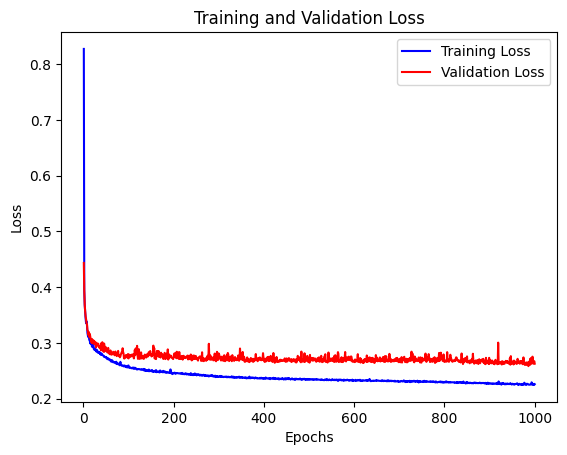

In [12]:
#Plotting Training Loss against Validation Loss
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(loss)+1)
plt.plot(epochs,loss,'b',label='Training Loss')
plt.plot(epochs,val_loss,'r',label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

 Here's how to interpret this graph:

* **The Y-axis (Value):** This axis represents the error. The goal is for these lines to be as low as possible, indicating less error.
The X-axis (Epochs): This shows the progress through the training process, with each point representing an epoch (one full pass over the training data).
* **The Blue Line (Training Loss)** : This line represents the Mean Squared Error (MSE) on your training data. You'll likely observe a rapid drop in this line during the initial epochs, and then it levels off. This 'elbow' shape suggests that your model quickly learned the fundamental patterns in the training data and then spent the remaining epochs fine-tuning its parameters.
* **The Red Line (Validation Loss)**: This line represents the Mean Absolute Error (MAE) on your validation data. In your case, it closely follows the training loss. If this line were to start increasing significantly while the training loss continued to decrease, it would be a strong indicator of overfitting (where the model learns the training data too well, including noise, and performs poorly on unseen data). However, since both lines are smooth and tend to level off without diverging, it suggests the model has converged well without significant overfitting during the observed epochs.

In summary, a healthy learning curve like this indicates that the model is learning effectively and generalizing reasonably well to new, unseen data, especially since the validation loss tracks the training loss without a significant upward trend.

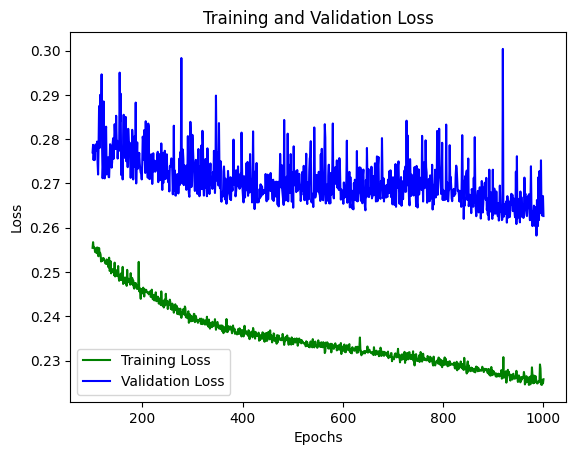

In [14]:
#Plotting Training Loss against Validation Loss - Dropping the first 100 epochs
SKIP=100
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(loss)+1)
plt.plot(epochs[SKIP:],loss[SKIP:],'g',label='Training Loss')
plt.plot(epochs[SKIP:],val_loss[SKIP:],'b',label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

This is a zoomed-in graph, by skipping the first 100 epochs.

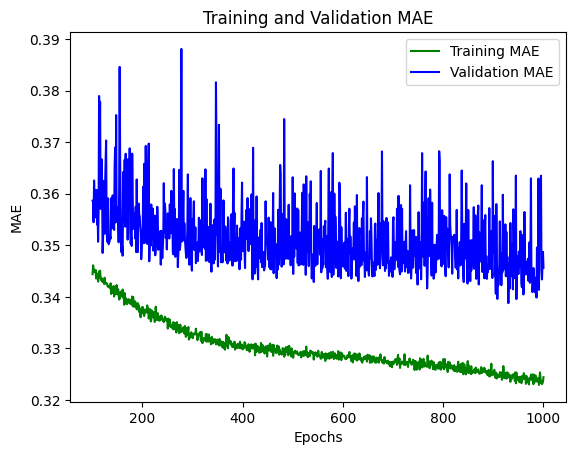

In [17]:
# Let us now plot  a graph for  MAE, which shows a different way of measuring the amount of error in the prediction.

mae = history.history['mean_absolute_error']
val_mae = history.history['val_mean_absolute_error']
epochs=range(1,len(loss)+1)
plt.plot(epochs[SKIP:],mae[SKIP:],'g',label='Training MAE')
plt.plot(epochs[SKIP:],val_mae[SKIP:],'b',label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

The graph showing 'Training and Validation MAE' (Mean Absolute Error) provides valuable insights into your model's performance:

* **The Y-axis (MAE):** This axis represents the average absolute difference between your model's predictions and the actual target values. In the context of California Housing, this would be the average error in predicting median house values (in thousands of dollars). A lower MAE indicates a more accurate model.
* **The X-axis (Epochs):** This continues to represent the number of training iterations, or full passes through your dataset.
The Green Line (Training MAE): This line shows how well your model is performing on the data it has already seen during training. You should observe a similar pattern to the training loss: a sharp decrease initially as the model quickly learns the basic patterns, followed by a leveling off as it fine-tunes its weights. This indicates the model is continuously improving its understanding of the training data.
* **The Blue Line (Validation MAE):** This line is crucial as it reflects how well your model generalizes to unseen data. Ideally, the validation MAE should track closely with the training MAE. If the validation MAE starts to increase significantly while the training MAE continues to decrease, it's a strong sign of overfitting. However, in this graph, both lines appear to decrease and then level off together without a significant divergence. This suggests that your model is generalizing well and not overfitting to the training data.

**Overall Interpretation:** The consistent decrease and eventual stabilization of both the training and validation MAE lines indicate that your model is learning effectively and has reached a point where further training might yield diminishing returns. The fact that the validation MAE remains close to the training MAE is a good sign that the model has learned robust patterns that are applicable to new, unseen data, rather than just memorizing the training set.

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


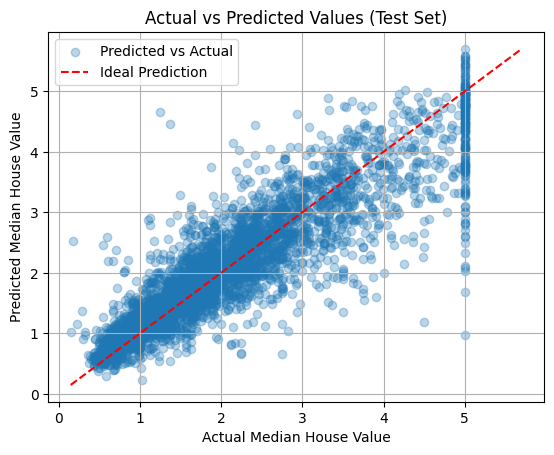

In [19]:
# Let us now  make a prediction to see how the model fits data.

predictions = model_housing.predict(X_test_scaled)

# We will then plot the prediction along with the test data

plt.clf()
plt.title('Actual vs Predicted Values (Test Set)')
# Flatten predictions to a 1D array for plotting if necessary
predictions_flat = predictions.flatten()

# Plot actual values vs predicted values
plt.scatter(y_test_20, predictions_flat, alpha=0.3, label='Predicted vs Actual')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')

# Add a diagonal line for ideal predictions (where Actual == Predicted)
min_val = min(y_test_20.min(), predictions_flat.min())
max_val = max(y_test_20.max(), predictions_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')

plt.legend()
plt.grid(True)
plt.show()